## Load Stock Data

In [24]:
import pandas as pd
stock_df = pd.read_csv("../data/raw/AAPL.csv")

### Data Quality Checks

In [25]:
# Check dataset shape
print("Dataset Shape:", stock_df.shape)

# Check data types
print(stock_df.dtypes)

# Check missing values
print(stock_df.isnull().sum())

Dataset Shape: (3774, 6)
Date          str
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


### Missing Value Handling

In [26]:
stock_df = stock_df.ffill()

In [27]:
# Check duplicate rows
print("Duplicate Rows:", stock_df.duplicated().sum())

Duplicate Rows: 0


In [28]:
stock_df = stock_df.sort_values(by="Date")

## Data Cleaning and Preparation

Before computing technical indicators, the dataset was inspected for missing values, incorrect data types, and duplicate records.

Missing values were handled using row removal/forward filling to ensure indicator calculations were not distorted. The dataset was also sorted chronologically because technical indicators depend on sequential time-series data.

### Duplicate Check

### Convert dates


In [29]:
stock_df["Date"] = pd.to_datetime(stock_df["Date"])

## Technical Indicators

### SMA

In [30]:
import talib

stock_df["SMA_20"] = talib.SMA(stock_df["Close"], timeperiod=20)

### EMA

In [31]:
stock_df["EMA_20"] = talib.EMA(stock_df["Close"], timeperiod=20)

### RSI

In [32]:
stock_df["RSI"] = talib.RSI(stock_df["Close"], timeperiod=14)

### MACD

In [33]:
macd, signal, hist = talib.MACD(stock_df["Close"])

stock_df["MACD"] = macd
stock_df["Signal"] = signal

## Visualization

### Price + Moving Averages

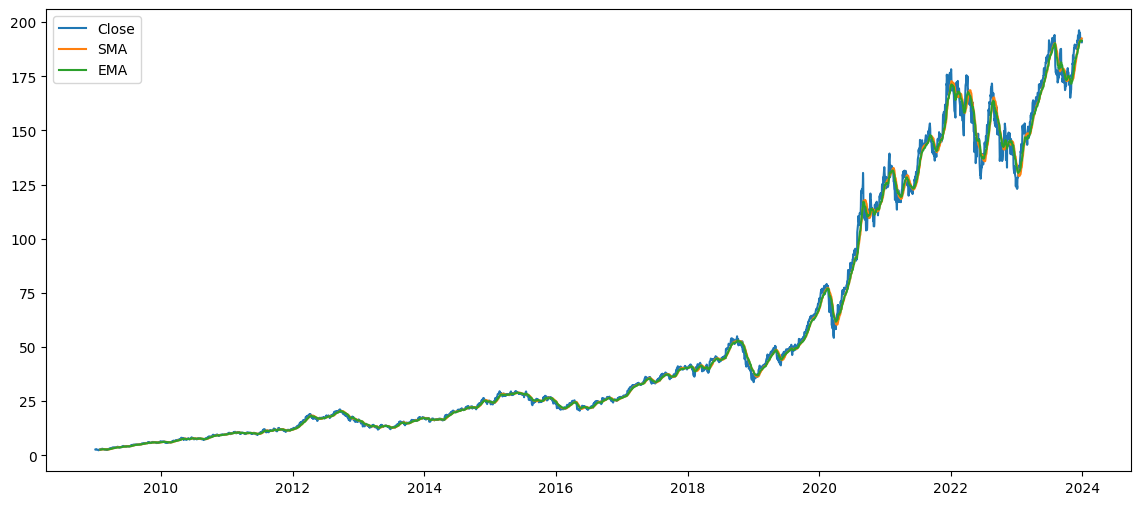

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))

plt.plot(stock_df["Date"], stock_df["Close"], label="Close")
plt.plot(stock_df["Date"], stock_df["SMA_20"], label="SMA")
plt.plot(stock_df["Date"], stock_df["EMA_20"], label="EMA")

plt.legend()
plt.show()

## Interpretation

This chart shows the historical closing price of a financial asset (likely a high-growth stock or index) from roughly 2009 through early 2024, overlaid with two technical indicators: a **Simple Moving Average (SMA)** and an **Exponential Moving Average (EMA)**.

### **1. Long-Term Price Action**

* **The Bullish Trend:** The asset shows a massive long-term uptrend. It spent nearly a decade (2009–2019) in a steady, controlled climb, rising from under $10 to approximately $50.
* **Volatility Injection:** Starting in 2020, the price action became significantly more "parabolic." While the overall direction remained up, the swings (volatility) became much larger, reaching peaks near $200.
* **Major Pullbacks:** You can clearly see the sharp "V-shaped" dip in early 2020 (likely the COVID-19 market crash) and a significant period of correction and consolidation throughout 2022.

---

### **2. Moving Average Comparison**

Moving averages are used to smooth out daily price "noise" to see the underlying trend.

* **SMA (Simple Moving Average - Orange):** This calculates the average price over a specific period. It reacts more slowly to recent price changes.
* **EMA (Exponential Moving Average - Green):** This places more weight on the most recent data.

**Key Observation:** In this specific graph, the SMA and EMA lines are very close to each other. This suggests that the look-back period (the number of days used for the average) is likely quite short—perhaps a 20-day or 50-day average. If it were a long-term average (like a 200-day), the lines would be much smoother and sit further away from the jagged blue price line.

---

### **3. Technical Interpretation**

* **Support Levels:** Throughout the trend, the moving averages (orange and green lines) act as "dynamic support." Whenever the blue price line dips and touches these averages, it frequently bounces back up, confirming a strong uptrend.
* **The 2022-2023 "Chop":** Look at the section between 2022 and 2024. The price crosses above and below the moving averages multiple times. This indicates a **period of consolidation** or a "range-bound" market where neither buyers nor sellers had clear control before the next breakout toward $200.
* **Lagging Indicators:** Notice that the averages stay below the price during fast rallies and stay above the price during sharp drops. This confirms they are "lagging" indicators—they tell you what the trend *has been*, rather than predicting exactly where it will go next.

### **Summary**

The graph depicts a highly successful asset that has transitioned from a low-volatility "slow crawl" to a high-volatility "growth" phase. As of the end of the chart (2024), the price is at all-time highs, and both moving averages are sloping upward, which technically signals a **continued bullish bias**.
